## Imports

In [1]:
# Step 1: Install Required Libraries
!pip install pandas bertopic nltk wordcloud scikit-learn matplotlib transformers umap-learn sentence-transformers -q


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Step 2: Import Libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from bertopic import BERTopic
import matplotlib.pyplot as plt
from transformers import pipeline

In [3]:
# Download NLTK Resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load Preprocessed Data

In [4]:
df = pd.read_csv("News Articles.csv")

In [5]:
df.head(5)

,headlines,description,content,url,category
0,Nirmala Sitharaman to equal Morarji Desai’s re...,With the presentation of the interim budget on...,"Sitharaman, the first full-time woman finance ...",https://indianexpress.com/article/business/bud...,business
1,"‘Will densify network, want to be at least no....","'In terms of market share, we aim to double it...",The merger of Tata group’s budget airlines Air...,https://indianexpress.com/article/business/avi...,business
2,Air India group to induct an aircraft every si...,Air India currently has 117 operational aircra...,The Air India group plans to induct one aircra...,https://indianexpress.com/article/business/avi...,business
3,Red Sea woes: Exporters seek increased credit ...,Rising attacks forced shippers to consider the...,Indian exporters have asked the central govern...,https://indianexpress.com/article/business/red...,business
4,Air India group to induct a plane every 6 days...,"Apart from fleet expansion, 2024 will also see...",The Air India group plans to induct one aircra...,https://indianexpress.com/article/business/avi...,business


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   headlines    10000 non-null  object
 1   description  10000 non-null  object
 2   content      10000 non-null  object
 3   url          10000 non-null  object
 4   category     10000 non-null  object
dtypes: object(5)
memory usage: 390.8+ KB


In [11]:
df.isnull().sum()

headlines      0
description    0
content        0
url            0
category       0
dtype: int64

### Combine fields into single column

In [12]:
# Combine fields into one text column
df.drop_duplicates(subset=['content'], inplace=True)
df["full_text"] = df["headlines"].astype(str) + " " + df["description"].astype(str) + " " + df["content"].astype(str)

## BERTopic model for Topics

In [18]:
# ✅ Step 7: Run BERTopic
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(df["full_text"])
df["topic"] = topics
df["topic_probability"] = probs

2025-06-03 11:42:58,611 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

2025-06-03 11:52:08,648 - BERTopic - Embedding - Completed ✓
2025-06-03 11:52:08,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-03 11:53:10,683 - BERTopic - Dimensionality - Completed ✓
2025-06-03 11:53:10,689 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-03 11:53:11,393 - BERTopic - Cluster - Completed ✓
2025-06-03 11:53:11,472 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-03 11:53:15,875 - BERTopic - Representation - Completed ✓


## Sentiment Analysis using Huggingface Pipeline

In [19]:
# Step 8: Sentiment Analysis using HuggingFace pipeline
sentiment_pipe = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [20]:
# Apply to each row (truncate to 512 tokens max)
df["sentiment"] = df["content"].fillna("").apply(lambda x: sentiment_pipe(x[:512])[0]["label"])

### Save File as "news_with_topics_and_sentiment"

In [22]:
# Optional – Save to CSV or push to ElasticSearch
df.to_csv("news_with_topics_and_sentiment.csv", index=False)
print("✅ Done! Data with topics and sentiment saved.")

✅ Done! Data with topics and sentiment saved.


In [23]:
data = pd.read_csv("news_with_topics_and_sentiment.csv")
data.head()

,headlines,description,content,url,category,full_text,topic,topic_probability,sentiment
0,Nirmala Sitharaman to equal Morarji Desai’s re...,With the presentation of the interim budget on...,"Sitharaman, the first full-time woman finance ...",https://indianexpress.com/article/business/bud...,business,Nirmala Sitharaman to equal Morarji Desai’s re...,-1,0.0,POSITIVE
1,"‘Will densify network, want to be at least no....","'In terms of market share, we aim to double it...",The merger of Tata group’s budget airlines Air...,https://indianexpress.com/article/business/avi...,business,"‘Will densify network, want to be at least no....",6,1.0,POSITIVE
2,Air India group to induct an aircraft every si...,Air India currently has 117 operational aircra...,The Air India group plans to induct one aircra...,https://indianexpress.com/article/business/avi...,business,Air India group to induct an aircraft every si...,6,1.0,POSITIVE
3,Red Sea woes: Exporters seek increased credit ...,Rising attacks forced shippers to consider the...,Indian exporters have asked the central govern...,https://indianexpress.com/article/business/red...,business,Red Sea woes: Exporters seek increased credit ...,202,1.0,NEGATIVE
4,Air India group to induct a plane every 6 days...,"Apart from fleet expansion, 2024 will also see...",The Air India group plans to induct one aircra...,https://indianexpress.com/article/business/avi...,business,Air India group to induct a plane every 6 days...,6,1.0,POSITIVE


In [24]:
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))

   Topic  Count                                 Name  \
0     -1   3179                     -1_and_the_of_in   
1      0    179           0_nifty_cent_sensex_points   
2      1    152   1_league_manchester_premier_united   
3      2    114        2_animal_ranbir_sandeep_reddy   
4      3    109               3_womens_cup_t20_world   
5      4     99  4_education_schools_school_teachers   
6      5     97               5_rukh_shah_khan_dunki   
7      6     90        6_air_aircraft_airline_boeing   
8      7     90      7_students_university_abroad_uk   
9      8     79      8_badminton_prannoy_sindhu_open   

                                      Representation  \
0   [and, the, of, in, to, for, that, is, with, was]   
1  [nifty, cent, sensex, points, per, markets, be...   
2  [league, manchester, premier, united, city, ar...   
3  [animal, ranbir, sandeep, reddy, vanga, kapoor...   
4  [womens, cup, t20, world, africa, south, austr...   
5  [education, schools, school, teachers, textb

In [25]:
# See the top keywords for topic 0
topic_model.get_topic(0)

[('nifty', np.float64(0.04166336013441828)),
 ('cent', np.float64(0.03127608746978903)),
 ('sensex', np.float64(0.030494936393569892)),
 ('points', np.float64(0.028872209265536387)),
 ('per', np.float64(0.027208548400982722)),
 ('markets', np.float64(0.019428985185586507)),
 ('benchmark', np.float64(0.019248009978481573)),
 ('bse', np.float64(0.018314168520283246)),
 ('bank', np.float64(0.015910494404275867)),
 ('indices', np.float64(0.014850705416598026))]

In [43]:
# See 3 sample headlines from topic 2
data[data["topic"] == 2][["headlines", "sentiment"]].sample(3)

,headlines,sentiment
5348,What Sandeep Reddy Vanga told Triptii Dimri ab...,POSITIVE
5634,Leo movie review: Adam Sandler’s mildly anarch...,NEGATIVE
5726,"20,000 Species of Bees, exploring a transgirl’...",POSITIVE


In [44]:
# Count how many articles are POSITIVE, NEGATIVE, NEUTRAL
data["sentiment"].value_counts()

sentiment
NEGATIVE    5330
POSITIVE    4661
Name: count, dtype: int64

In [45]:
# View NEGATIVE articles (maybe biased or controversial ones)
data[data["sentiment"] == "NEGATIVE"][["headlines", "topic"]].head()

,headlines,topic
3,Red Sea woes: Exporters seek increased credit ...,202
5,"Q3 Earnings Results: JSW Steel, PNB, ACC repor...",76
6,Blackstone’s fourth-quarter earnings rise 4% a...,76
8,India-UK FTA: Final push for deal as window cl...,28
9,Govt close to saturation in implementing socia...,-1


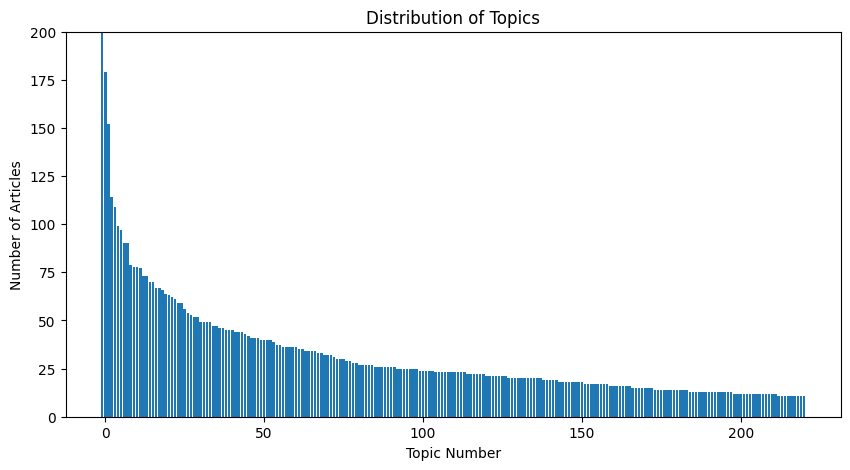

In [46]:
topic_counts = data["topic"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel("Topic Number")
plt.ylabel("Number of Articles")
plt.title("Distribution of Topics")
plt.ylim(0, 200)  
plt.show()

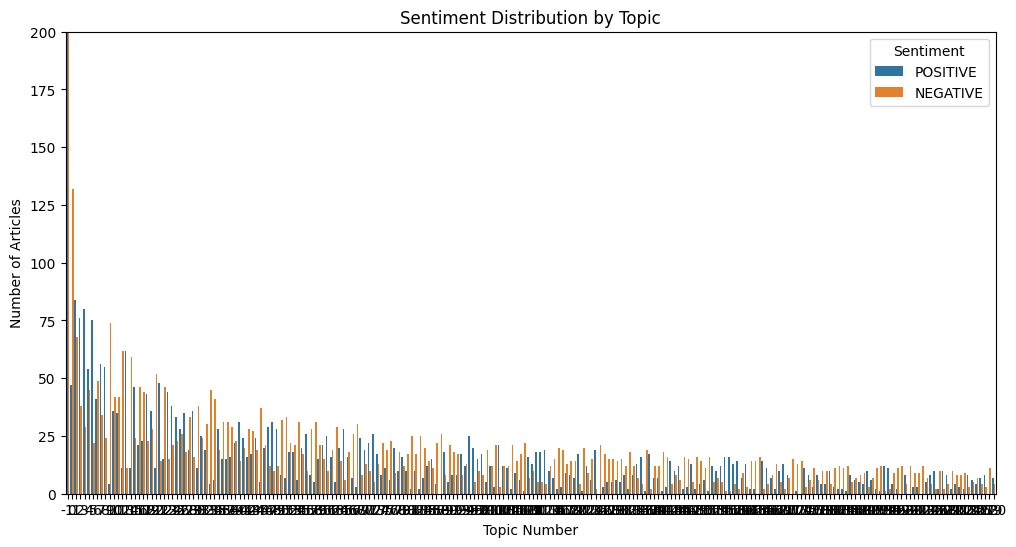

In [34]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="topic", hue="sentiment")
plt.title("Sentiment Distribution by Topic")
plt.xlabel("Topic Number")
plt.ylabel("Number of Articles")
plt.ylim(0, 200)  
plt.legend(title="Sentiment")
plt.show()

<Axes: xlabel='timestamp'>

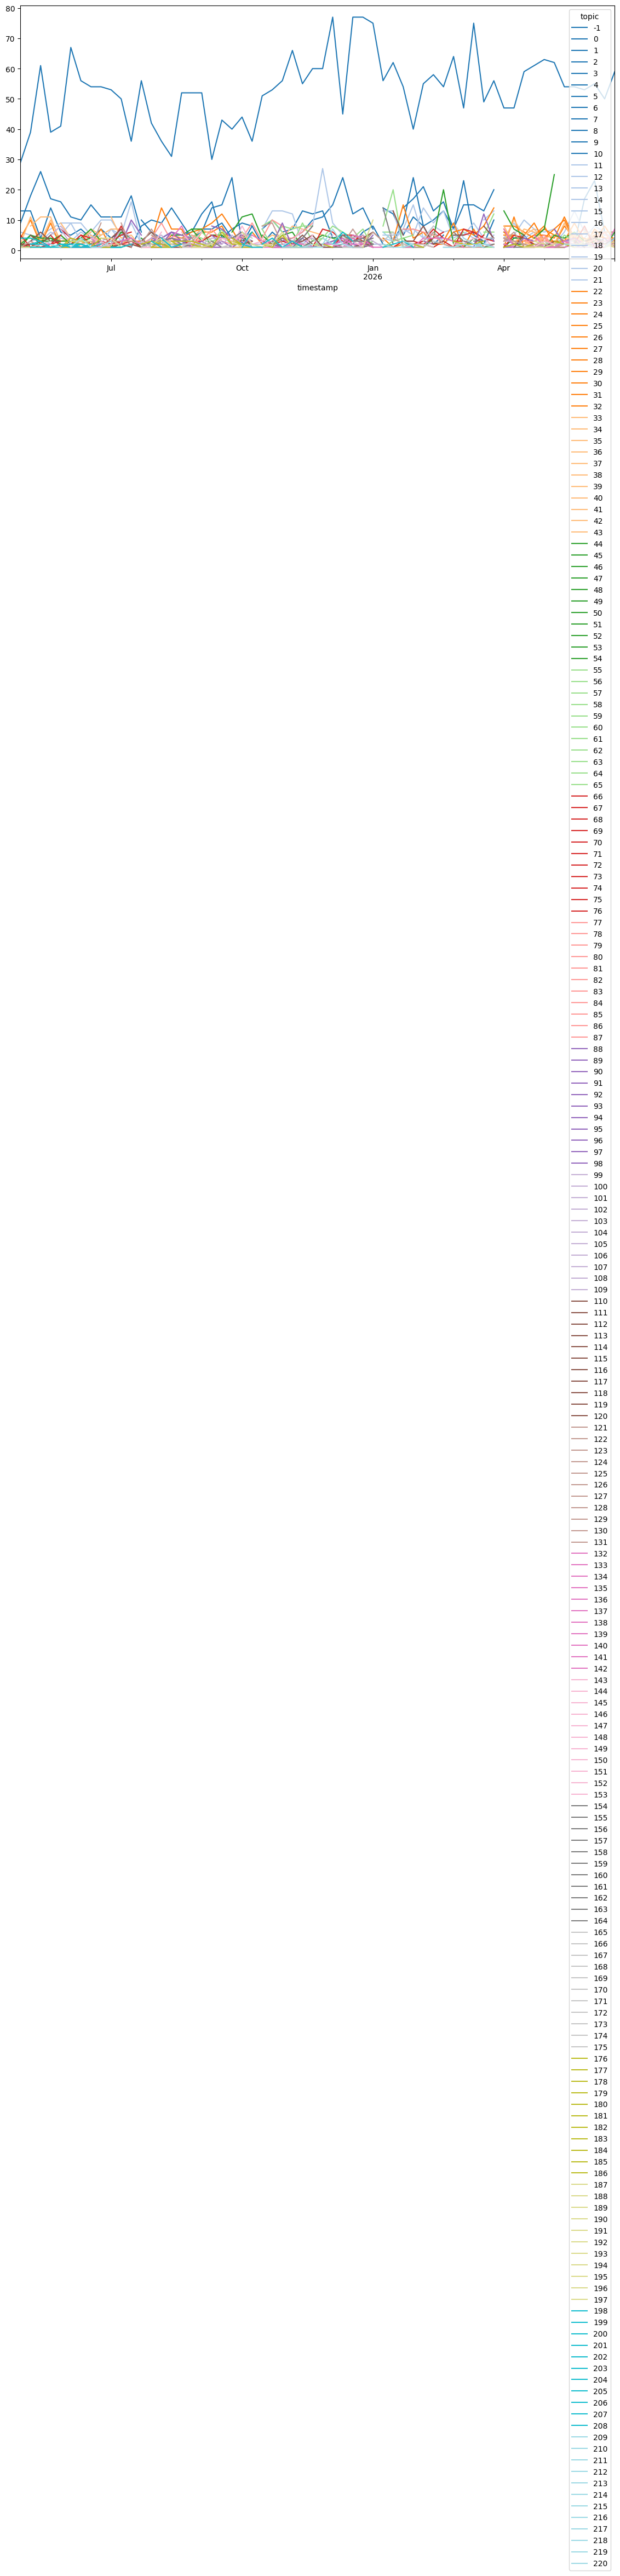

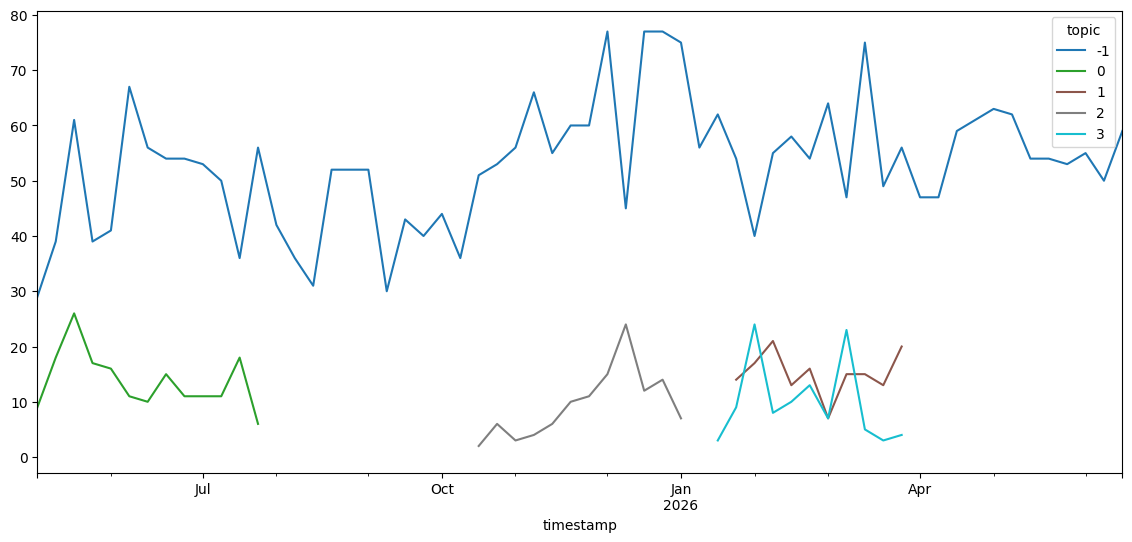

In [41]:
# Example: generate random dates for demo
df["timestamp"] = pd.date_range("2025-05-01", periods=len(df), freq="H")

df.groupby(df["timestamp"].dt.to_period("W"))["topic"] \
  .value_counts().unstack().plot(figsize=(14,6), colormap="tab20")
# Get top 5 most frequent topics
top_topics = df["topic"].value_counts().head(5).index.tolist()

# Filter and plot
df[df["topic"].isin(top_topics)] \
  .groupby(df["timestamp"].dt.to_period("W"))["topic"] \
  .value_counts().unstack().plot(figsize=(14,6), colormap="tab10")

<Axes: xlabel='timestamp'>

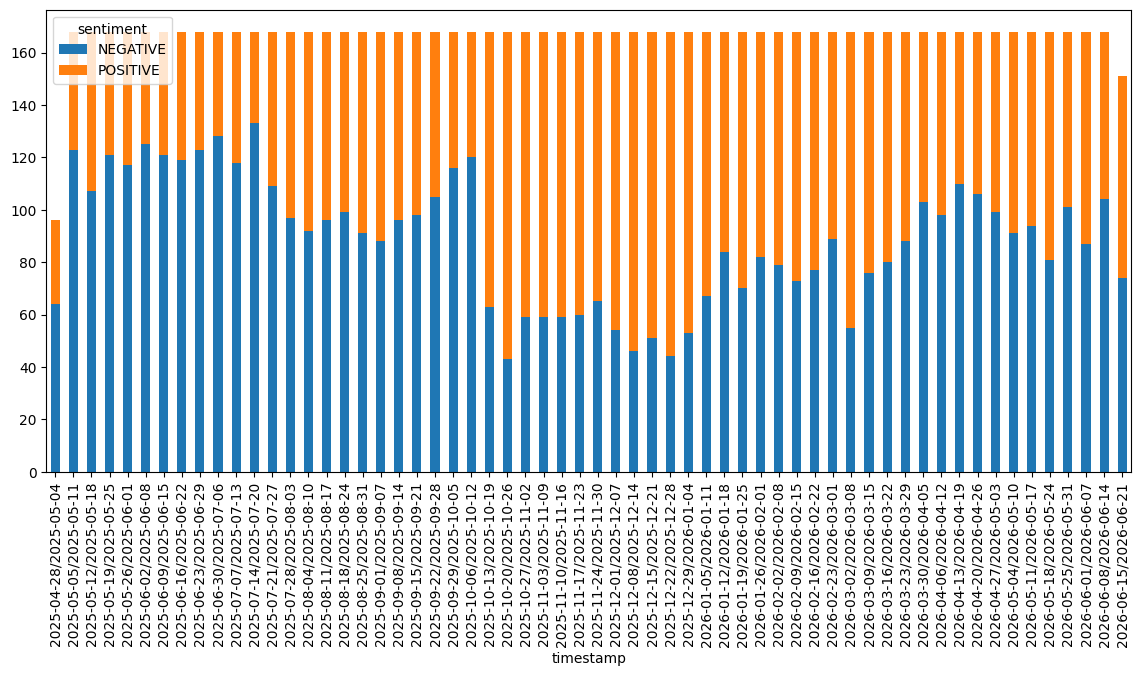

In [42]:
df.groupby([df["timestamp"].dt.to_period("W"), "sentiment"]) \
  .size().unstack().plot(kind="bar", stacked=True, figsize=(14,6))


In [38]:
from elasticsearch import Elasticsearch
es = Elasticsearch("http://localhost:9200")
index_name = "news-trends"

for i, row in df.iterrows():
    es.index(index=index_name, document=row.to_dict())

ConnectionError: Connection error caused by: ConnectionError(Connection error caused by: NewConnectionError(<urllib3.connection.HTTPConnection object at 0x0000025EB2E90BF0>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it))

In [40]:
category_groups = df.groupby("category")

for category, group_df in category_groups:
    topic_model = BERTopic()
    topics, _ = topic_model.fit_transform(group_df["full_text"])
    print(f"Top topics for category {category}:")
    print(topic_model.get_topic_info().head(3))

Top topics for category business:
   Topic  Count                           Name  \
0     -1    473                -1_the_of_in_to   
1      0    189        0_nifty_points_cent_per   
2      1     93  1_air_aircraft_airline_boeing   

                                      Representation  \
0    [the, of, in, to, and, said, for, is, rs, that]   
1  [nifty, points, cent, per, sensex, or, markets...   
2  [air, aircraft, airline, boeing, airlines, avi...   

                                 Representative_Docs  
0  [Global economy’s glide to ‘soft landing’ gets...  
1  [Sensex, Nifty erase gains, end flat; broader ...  
2  [DGCA orders Indian carriers to inspect emerge...  
Top topics for category education:
   Topic  Count                            Name  \
0     -1    369                -1_the_of_and_in   
1      0    100  0_schools_education_school_the   
2      1     91           1_in_to_abroad_indian   

                                      Representation  \
0   [the, of, and, in, t